In [1]:
import copy
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [2]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TARGET = ['% Iron Concentrate', '% Silica Concentrate']  # columnas a predecir
HORIZON = 1  # horas -- se predice el valor de TARGET dentro de HORIZON horas

df = pd.read_csv(filepath, decimal=',')
df['date'] = pd.to_datetime(df['date'])

# Columnas de laboratorio: se miden una vez por hora y aparecen repetidas en el CSV
# crudo en cada fila de 20s de esa hora (no son 180 medidas independientes).
lab_cols = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]



In [3]:
# --- 1. Fix the Time Index (The Crucial Step) ---
# df.groupby('date').cumcount() counts the position of each duplicate (0 to 179)
# We multiply that position by 20 seconds and add it to the base timestamp
time_offsets = pd.to_timedelta(df.groupby('date').cumcount() * 20, unit='s')

# Build a precise timeline from the 'date' column + offset (the row index itself
# is just 0..N-1, it is not a datetime, so we cannot add timedeltas to it directly)
df.index = df['date'] + time_offsets

# --- 2. Filter the Bad Range ---
start_remove = '2017-03-10 01:00:00'
end_remove = '2017-03-29 11:01:00'

# Create mask and apply it
mask = (df.index < start_remove) | (df.index > end_remove)
df = df[mask]

# Drop the empty 19-day gap created by resampling
df = df.dropna()

In [4]:
# Limpieza de outliers por ventana
numeric_df = df.select_dtypes(include=[np.number])

# #### windowed outlier detection using rolling IQR
window_size = 180 # Adjust based on your signal's frequency

# # Calculate rolling quartiles
Q1_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.25)
Q3_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.75)
IQR_rolling = Q3_rolling - Q1_rolling

# Calculate dynamic bounds
lower_bound_rolling = Q1_rolling - 1.5 * IQR_rolling
upper_bound_rolling = Q3_rolling + 1.5 * IQR_rolling

# En vez de descartar la fila entera cuando una sola columna se sale de rango,
# recortamos (winsorize) cada valor a su limite mas cercano: perdemos el valor
# extremo pero conservamos la fila y el resto de columnas de esa lectura.
n_outliers = ((numeric_df < lower_bound_rolling) | (numeric_df > upper_bound_rolling)).sum().sum()
df[numeric_df.columns] = numeric_df.clip(lower=lower_bound_rolling, upper=upper_bound_rolling, axis=0)

print(f"Row count: {len(df)}")
print(f"Valores recortados (winsorized): {n_outliers}")

Row count: 710639
Valores recortados (winsorized): 299428


In [5]:
# Promedia señales con alta correlación
air_flow_6_7 = [
    'Flotation Column 06 Air Flow', 
    'Flotation Column 07 Air Flow'
]

air_flow_1_2_3 = [
    'Flotation Column 01 Air Flow', 
    'Flotation Column 02 Air Flow', 
    'Flotation Column 03 Air Flow'
]

silica_iron_feed = [
    '% Iron Feed',  
    '% Silica Feed'
]

level_4_5_6_7 = [
    'Flotation Column 04 Level',  
    'Flotation Column 05 Level',
    'Flotation Column 06 Level',  
    'Flotation Column 07 Level'
]

level_1_2_3 = [
    'Flotation Column 01 Level',  
    'Flotation Column 02 Level',
    'Flotation Column 03 Level'
]

# Calculate the row-wise mean for each group and assign to new columns
df['Air Flow 6_7_Mean'] = df[air_flow_6_7].mean(axis=1)
df['Air Flow 1_2_3_Mean'] = df[air_flow_1_2_3].mean(axis=1)
df['Feed Iron_Silica_Mean'] = df[silica_iron_feed].mean(axis=1)
df['Level 4_5_6_7_Mean'] = df[level_4_5_6_7].mean(axis=1)
df['Level 1_2_3_Mean'] = df[level_1_2_3].mean(axis=1)

# Combine the lists and drop the original features
columns_to_drop = air_flow_6_7 + air_flow_1_2_3 + silica_iron_feed + level_4_5_6_7 + level_1_2_3
df = df.drop(columns=columns_to_drop)

# '% Iron Feed' y '% Silica Feed' se fusionaron en 'Feed Iron_Silica_Mean';
# actualizamos lab_cols para que siga reflejando las columnas de laboratorio reales.
lab_cols = [c for c in lab_cols if c not in silica_iron_feed] + ['Feed Iron_Silica_Mean']

# sensor_cols apuntaba a los nombres originales (antes de combinar columnas
# correlacionadas); lo recalculamos contra las columnas reales de df para no
# perder las combinadas (Air Flow 6_7_Mean, Air Flow 1_2_3_Mean, Level ..._Mean).
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]

# Version sin features (solo media horaria por sensor, sin slope/std) para
# visualizacion externa. Distinta del df de trabajo: no se modifica df aqui.
agg_viz = {c: 'mean' for c in sensor_cols}
agg_viz.update({c: 'first' for c in lab_cols})
df_viz = df.groupby('date', as_index=True).agg(agg_viz).sort_index()
df_viz.to_csv('forecasting_data_historical.csv', index=True)

In [6]:
# Antes de agregar a resolucion horaria: para cada sensor rapido calculamos,
# sobre los ultimos 30 puntos (de 20s) de cada hora, la media, la pendiente de
# regresion lineal (tendencia dentro de la hora) y la desviacion estandar.
# Estas 3 features capturan mas informacion que un simple promedio horario.
def _slope(y):
    y = y.to_numpy()
    n = len(y)
    if n < 2:
        return np.nan
    x = np.arange(n)
    return np.polyfit(x, y, 1)[0]

last30 = df.groupby('date')[sensor_cols].tail(30).groupby(df['date'])
feat_mean = last30.mean().add_suffix('_mean')
feat_slope = last30.apply(lambda g: g.apply(_slope)).add_suffix('_slope')
feat_std = last30.std().add_suffix('_std')

sensor_features = pd.concat([feat_mean, feat_slope, feat_std], axis=1)

# Agregamos a resolucion horaria: 'first' para las columnas de laboratorio
# (todas las filas de la hora ya comparten el mismo valor); los sensores
# rapidos ya se resumieron arriba en sensor_features (media/pendiente/std).
agg = {c: 'first' for c in lab_cols}
df = df.groupby('date', as_index=True).agg(agg).sort_index()
df = df.join(sensor_features)
print(f"File parameters: {df.columns}")
# Rellenamos huecos horarios que falten en el indice (haberlos hay: la campana no
# es perfectamente continua) e interpolamos linealmente.
full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
n_missing_hours = len(full_range.difference(df.index))
print(f"Missing hours in original index: {n_missing_hours}")
df = df.reindex(full_range)

for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].ffill()

print(f"Filas (horas): {len(df)} | horas que faltaban en el indice original y se rellenaron: {n_missing_hours}")
print(df[TARGET].describe())

File parameters: Index(['% Iron Concentrate', '% Silica Concentrate', 'Feed Iron_Silica_Mean',
       'Starch Flow_mean', 'Amina Flow_mean', 'Ore Pulp Flow_mean',
       'Ore Pulp pH_mean', 'Ore Pulp Density_mean',
       'Flotation Column 04 Air Flow_mean',
       'Flotation Column 05 Air Flow_mean', 'Air Flow 6_7_Mean_mean',
       'Air Flow 1_2_3_Mean_mean', 'Level 4_5_6_7_Mean_mean',
       'Level 1_2_3_Mean_mean', 'Starch Flow_slope', 'Amina Flow_slope',
       'Ore Pulp Flow_slope', 'Ore Pulp pH_slope', 'Ore Pulp Density_slope',
       'Flotation Column 04 Air Flow_slope',
       'Flotation Column 05 Air Flow_slope', 'Air Flow 6_7_Mean_slope',
       'Air Flow 1_2_3_Mean_slope', 'Level 4_5_6_7_Mean_slope',
       'Level 1_2_3_Mean_slope', 'Starch Flow_std', 'Amina Flow_std',
       'Ore Pulp Flow_std', 'Ore Pulp pH_std', 'Ore Pulp Density_std',
       'Flotation Column 04 Air Flow_std', 'Flotation Column 05 Air Flow_std',
       'Air Flow 6_7_Mean_std', 'Air Flow 1_2_3_Mean_std',

In [7]:
# Comprobar la correlacion entre las señales target y las features de laboratorio
# Para cada variable de proceso candidata (elige 3-5 que físicamente deberían
# tener relación causal directa y rápida con sílice/iron, ej. % feed, flujo de aire)
def cross_correlation_lag(sensor, target, max_lag_hours=6):
    sensor_norm = (sensor - sensor.mean()) / sensor.std()
    target_norm = (target - target.mean()) / target.std()
    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        if lag < 0:
            c = np.corrcoef(sensor_norm[:lag], target_norm[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(sensor_norm[lag:], target_norm[:-lag])[0, 1]
        else:
            c = np.corrcoef(sensor_norm, target_norm)[0, 1]
        correlations.append((lag, c))
    return correlations

for target in TARGET:
    print(f"\nCross-correlation for target: {target}")
    for sensor in df.columns:

        if not "mean" in sensor:
            continue
        correlations = cross_correlation_lag(df[sensor], df[target])

        max_corr = max(correlations, key=lambda x: abs(x[1]))
        print(f"Max correlation in {sensor} at lag {max_corr[0]} hours: {max_corr[1]:.4f}")



Cross-correlation for target: % Iron Concentrate
Max correlation in Starch Flow_mean at lag 4 hours: 0.0963
Max correlation in Amina Flow_mean at lag 2 hours: -0.1902
Max correlation in Ore Pulp Flow_mean at lag -6 hours: 0.1080
Max correlation in Ore Pulp pH_mean at lag -4 hours: 0.2232
Max correlation in Ore Pulp Density_mean at lag 5 hours: 0.0265
Max correlation in Flotation Column 04 Air Flow_mean at lag 6 hours: -0.0491
Max correlation in Flotation Column 05 Air Flow_mean at lag -3 hours: 0.0717
Max correlation in Air Flow 6_7_Mean_mean at lag -4 hours: 0.0220
Max correlation in Air Flow 1_2_3_Mean_mean at lag -3 hours: 0.1285
Max correlation in Level 4_5_6_7_Mean_mean at lag 6 hours: 0.2386
Max correlation in Level 1_2_3_Mean_mean at lag -3 hours: -0.0451

Cross-correlation for target: % Silica Concentrate
Max correlation in Starch Flow_mean at lag 4 hours: -0.1173
Max correlation in Amina Flow_mean at lag 2 hours: 0.2425
Max correlation in Ore Pulp Flow_mean at lag 6 hours: -0

In [8]:
import pandas as pd
import numpy as np

def cross_correlation_clean(df, sensor_col, target_col, max_lag_hours=6, 
                              max_gap_hours=1, min_run_length=15):
    """
    Cross-correlation entre sensor y target, excluyendo:
    - Filas donde el target está "congelado" (racha larga sin actualización real)
    - Pares (sensor(t), target(t+lag)) donde el hueco temporal entre t y t+lag
      excede max_gap_hours veces el lag esperado (evita mezclar costuras)
    
    df: DataFrame con index datetime, ordenado ascendente
    max_gap_hours: tolerancia de irregularidad en el muestreo horario (normalmente 1)
    min_run_length: mínimo de horas consecutivas de actualización real del target
                     para considerar ese tramo válido
    """
    df = df.copy()
    df = df.sort_index()

    # 1. Identificar rachas de valores repetidos (target "congelado")
    is_repeated = df[target_col].diff() == 0
    run_id = (~is_repeated).cumsum()
    run_lengths = df.groupby(run_id)[target_col].transform('size')

    # 2. Válido = racha corta (no congelado) Y no es el primer punto de una racha larga
    #    (ajusta el umbral: aquí descartamos cualquier fila que pertenezca a una
    #    racha de longitud >= min_run_length, asumiendo que esas son congelamiento,
    #    no proceso genuinamente estable)
    valid_mask = run_lengths < min_run_length
    df_valid = df.loc[valid_mask, [sensor_col, target_col]].copy()

    if len(df_valid) < 50:
        raise ValueError(f"Muy pocos puntos válidos tras filtrar ({len(df_valid)}). Revisa min_run_length.")

    sensor = df_valid[sensor_col]
    target = df_valid[target_col]

    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        if lag == 0:
            s_shifted = sensor
            t_aligned = target
        elif lag > 0:
            # sensor(t) predice target(t+lag): comparamos sensor(t) con target
            # desplazado hacia atrás 'lag' posiciones EN TIEMPO REAL, no en índice
            t_shifted_index = target.index - pd.Timedelta(hours=lag)
            # Solo nos quedamos con sensores cuyo timestamp+lag caiga exactamente
            # en un timestamp real presente en target (evita mezclar costuras)
            common_idx = sensor.index.intersection(t_shifted_index)
            if len(common_idx) < 30:
                correlations.append((lag, np.nan, len(common_idx)))
                continue
            s_shifted = sensor.loc[common_idx]
            t_aligned = target.loc[common_idx + pd.Timedelta(hours=lag)].values
            t_aligned = pd.Series(t_aligned, index=common_idx)
        else:
            lag_abs = abs(lag)
            s_shifted_index = sensor.index - pd.Timedelta(hours=lag_abs)
            common_idx = target.index.intersection(s_shifted_index)
            if len(common_idx) < 30:
                correlations.append((lag, np.nan, len(common_idx)))
                continue
            t_aligned = target.loc[common_idx]
            s_shifted = sensor.loc[common_idx + pd.Timedelta(hours=lag_abs)].values
            s_shifted = pd.Series(s_shifted, index=common_idx)

        if lag == 0:
            valid_pairs = pd.concat([s_shifted, t_aligned], axis=1).dropna()
            n_pairs = len(valid_pairs)
            if n_pairs < 30:
                correlations.append((lag, np.nan, n_pairs))
                continue
            c = np.corrcoef(valid_pairs.iloc[:, 0], valid_pairs.iloc[:, 1])[0, 1]
        else:
            n_pairs = len(s_shifted)
            c = np.corrcoef(s_shifted, t_aligned)[0, 1]

        correlations.append((lag, c, n_pairs))

    result = pd.DataFrame(correlations, columns=['lag_hours', 'correlation', 'n_pairs'])
    return result

# Uso, con corrección por comparaciones múltiples ya incorporada al criterio:
sensor_cols = ['Amina Flow_mean', 'Level 4_5_6_7_Mean_mean', 'Starch Flow_mean', 'Ore Pulp pH_mean']  # solo las candidatas, no las 20
targets = ['% Iron Concentrate', '% Silica Concentrate']  # lista de columnas de target

n_tests = len(sensor_cols) * 13 * len(targets)  # 13 = lags de -6 a 6
bonferroni_threshold_n = 30  # ajusta según tu tamaño de muestra real tras filtrar
# calcula el umbral de significancia real con scipy.stats si quieres ser riguroso

for target_name in targets:
    print(f"\n=== {target_name} ===")
    for sensor_col in sensor_cols:
        print(f"\nSensor: {sensor_col}")
        res = cross_correlation_clean(df, sensor_col, target_name, 
                                        max_lag_hours=6, min_run_length=15)
        print(res)
        # best = res.loc[res['correlation'].abs().idxmax()]
        # print(f"{sensor_col}: mejor lag={best['lag_hours']:.0f}h, "
        #       f"r={best['correlation']:.4f}, n_pares={best['n_pairs']:.0f}")


=== % Iron Concentrate ===

Sensor: Amina Flow_mean
    lag_hours  correlation  n_pairs
0          -6    -0.153421     3645
1          -5    -0.172700     3655
2          -4    -0.197052     3665
3          -3    -0.215121     3675
4          -2    -0.220715     3685
5          -1    -0.182025     3695
6           0    -0.149887     3705
7           1    -0.123734     3695
8           2    -0.089429     3685
9           3    -0.067802     3675
10          4    -0.056556     3665
11          5    -0.035949     3655
12          6    -0.034914     3645

Sensor: Level 4_5_6_7_Mean_mean
    lag_hours  correlation  n_pairs
0          -6     0.266667     3645
1          -5     0.261470     3655
2          -4     0.263626     3665
3          -3     0.246914     3675
4          -2     0.230293     3685
5          -1     0.205177     3695
6           0     0.184630     3705
7           1     0.169919     3695
8           2     0.155207     3685
9           3     0.151115     3675
10          4 

              target                        input  best_lag_xcorr  |xcorr|  best_lag_mi       mi
  % Iron Concentrate        Feed Iron_Silica_Mean               5 0.082875            1 0.417529
  % Iron Concentrate             Level 1_2_3_Mean               3 0.058364           10 0.198090
  % Iron Concentrate Flotation Column 04 Air Flow              12 0.079247            8 0.171093
  % Iron Concentrate          Air Flow 1_2_3_Mean               3 0.225930            8 0.168662
  % Iron Concentrate Flotation Column 05 Air Flow              12 0.022818            0 0.158202
  % Iron Concentrate             Ore Pulp Density              12 0.047359            0 0.137944
  % Iron Concentrate           Level 4_5_6_7_Mean               0 0.152825            5 0.118567
  % Iron Concentrate                   Amina Flow               0 0.078166            0 0.100500
  % Iron Concentrate            Air Flow 6_7_Mean               3 0.156475            9 0.098502
  % Iron Concentrate          

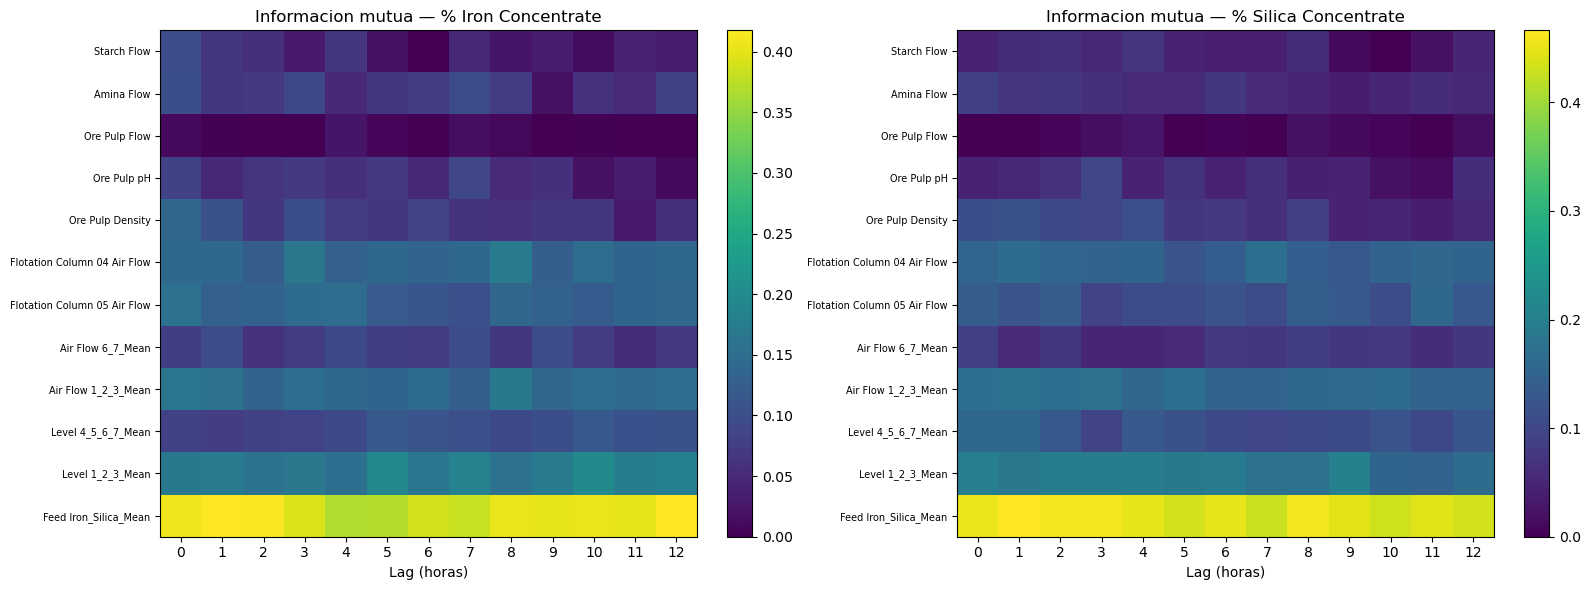

Umbral de ruido (MI, percentil 95 sobre target barajado):
  % Iron Concentrate: 0.0357
  % Silica Concentrate: 0.0398

3 lags plausibles seleccionados (orden de mayor a menor MI validado):
                input  lag               target       mi
Feed Iron_Silica_Mean    1 % Silica Concentrate 0.466244
     Level 1_2_3_Mean    9 % Silica Concentrate 0.202809
  Air Flow 1_2_3_Mean    1 % Silica Concentrate 0.177435


In [9]:
# --- Correlacion cruzada + informacion mutua vs. lag, por señal de entrada ---
# Objetivo: para cada parametro de entrada (solo los "crudos" agregados a la
# hora: sensores + columnas de laboratorio, SIN las features derivadas
# _mean/_slope/_std), ver a que lag esta mas relacionado con cada target y con
# que fuerza, para decidir que lags merece la pena meter como input al modelo.
#
# - Correlacion cruzada (lineal, con signo): corr(input(t-lag), target(t))
# - Informacion mutua (no lineal, sin signo): capta cualquier dependencia,
#   incluida no monotona, pero no dice si la relacion es directa o inversa.
#
# Se usa df_viz (agregacion horaria simple, sin features derivadas) y SOLO el
# tramo de train para no filtrar informacion del test en la seleccion de lags.
from sklearn.feature_selection import mutual_info_regression

MAX_LAG = 12  # horas
input_cols = [c for c in df_viz.columns if c not in TARGET]

train_cutoff = df_viz.index[int(len(df_viz) * 0.70)]
df_viz_train = df_viz.loc[:train_cutoff]

xcorr_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}
mi_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}

for target_col in TARGET:
    y = df_viz_train[target_col]
    for lag in range(MAX_LAG + 1):
        shifted = df_viz_train[input_cols].shift(lag)
        valid = shifted.join(y, how='inner').dropna()
        if len(valid) < 30:
            continue
        X_lag = valid[input_cols]
        y_lag = valid[target_col]

        xcorr_results[target_col][lag] = X_lag.corrwith(y_lag)

        mi = mutual_info_regression(X_lag, y_lag, random_state=21)
        mi_results[target_col][lag] = mi

# --- Mejor lag por señal segun cada criterio ---
summary_rows = []
for target_col in TARGET:
    best_xcorr_lag = xcorr_results[target_col].abs().idxmax(axis=1)
    best_xcorr_val = xcorr_results[target_col].abs().max(axis=1)
    best_mi_lag = mi_results[target_col].idxmax(axis=1)
    best_mi_val = mi_results[target_col].max(axis=1)
    for col in input_cols:
        summary_rows.append({
            'target': target_col,
            'input': col,
            'best_lag_xcorr': best_xcorr_lag[col],
            '|xcorr|': best_xcorr_val[col],
            'best_lag_mi': best_mi_lag[col],
            'mi': best_mi_val[col],
        })

summary = pd.DataFrame(summary_rows).sort_values(['target', 'mi'], ascending=[True, False])
print(summary.to_string(index=False))

# --- Heatmaps: fuerza de relacion (MI) por señal x lag, un heatmap por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(8 * len(TARGET), 6))
for ax, target_col in zip(axes, TARGET):
    im = ax.imshow(mi_results[target_col].values, aspect='auto', cmap='viridis')
    ax.set_yticks(range(len(input_cols)))
    ax.set_yticklabels(input_cols, fontsize=7)
    ax.set_xticks(range(MAX_LAG + 1))
    ax.set_xlabel('Lag (horas)')
    ax.set_title(f'Informacion mutua — {target_col}')
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# --- Umbral de ruido por permutacion: MI que se obtendria por puro azar ---
# La MI estimada por k-NN nunca es exactamente 0 aunque no haya relacion real,
# asi que no hay un umbral absoluto "bueno". Para saber si un MI observado es
# plausible (no ruido de estimacion) lo comparamos contra la distribucion de MI
# que se obtiene barajando el target (rompe la relacion temporal real) muchas
# veces: cualquier MI observado por debajo del percentil 95 de ese ruido no es
# distinguible de una relacion espuria.
N_PERMUTATIONS = 50
rng = np.random.default_rng(21)
noise_mi = {t: [] for t in TARGET}

for target_col in TARGET:
    y = df_viz_train[target_col].dropna()
    X = df_viz_train.loc[y.index, input_cols]
    for _ in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y.values)
        mi_noise = mutual_info_regression(X, y_shuffled, random_state=21)
        noise_mi[target_col].append(mi_noise.max())  # el maximo entre señales es el criterio mas estricto

noise_threshold = {t: np.percentile(noise_mi[t], 95) for t in TARGET}
print('Umbral de ruido (MI, percentil 95 sobre target barajado):')
for t in TARGET:
    print(f'  {t}: {noise_threshold[t]:.4f}')

# --- Seleccion final: 3 pares (señal, lag) GLOBALES, señales distintas entre si,
# con MI por encima del umbral de ruido, ordenados de mayor a menor MI. Para
# combinar ambos targets se recorren los candidatos de los dos a la vez y se
# toma, por cada señal, el mejor par (target, lag) que aparezca primero en el
# ranking conjunto.
candidates = []
for target_col in TARGET:
    for col in input_cols:
        for lag in range(MAX_LAG + 1):
            mi_val = mi_results[target_col].loc[col, lag]
            if pd.notna(mi_val) and mi_val >= noise_threshold[target_col]:
                candidates.append({'input': col, 'lag': lag, 'target': target_col, 'mi': mi_val})

candidates_df = pd.DataFrame(candidates).sort_values('mi', ascending=False)

selected = []
used_inputs = set()
for _, row in candidates_df.iterrows():
    if row['input'] in used_inputs:
        continue
    selected.append(row)
    used_inputs.add(row['input'])
    if len(selected) == 3:
        break

selected_lags = pd.DataFrame(selected)[['input', 'lag', 'target', 'mi']].reset_index(drop=True)
print('\n3 lags plausibles seleccionados (orden de mayor a menor MI validado):')
print(selected_lags.to_string(index=False))

In [19]:
# --- 2. Features reducidas: SOLO estas 3, nada mas ---
FEATURE_COLS_LAG_0 = [
    'Ore Pulp Density_mean',
    'Flotation Column 05 Air Flow_mean',
    'Amina Flow_mean'
]
FEATURE_COLS_LAG_1 = [
    'Feed Iron_Silica_Mean',
    'Air Flow 1_2_3_Mean_mean',
    'Ore Pulp Density_mean'
]

FEATURE_COLS_LAG_3 = [
    'Ore Pulp pH_mean'
]

lag_per_feature = {
    0: FEATURE_COLS_LAG_0,
    1: FEATURE_COLS_LAG_1,
    3: FEATURE_COLS_LAG_3
}

# Construir cada lag de forma separada y luego concatenarlas para tener un X final con todas las features y sus lags
for lag, features in lag_per_feature.items():
    lagged_features = df[features].shift(lag)
    lagged_features.columns = [f"{c}_lag{lag}" for c in lagged_features.columns]
    
    if lag == 0:
        X_all = lagged_features
    else:
        X_all = pd.concat([X_all, lagged_features], axis=1)


# # Construir X con lag 1 explicito para TODAS las features (incluido el propio target)
# X_all = df[FEATURE_COLS].shift(1)   # todo lo disponible en t-1
# X_all.columns = [f"{c}_lag1" for c in X_all.columns]

y_all = df[TARGET].copy()  # target real en t (que tras el shift de X es t = t-1+1)

# Alinear: quitar la primera fila (sin lag disponible) y cualquier NaN por el filtrado de rachas
valid_rows = X_all.dropna().index.intersection(y_all.dropna().index)
X_all = X_all.loc[valid_rows]
y_all = y_all.loc[valid_rows]


In [66]:
from sklearn.multioutput import MultiOutputRegressor

# # Features = everything except the TARGET (TARGET defined above)
# FEATURE_COLS = [c for c in df.columns if c not in TARGET]

# # Forecasting real a HORIZON horas vista: las features de la fila t describen
# # lo que paso HASTA la hora t (sensores + estadisticos de esa hora), y el target
# # es el valor real medido en t+HORIZON. Sin este shift el modelo estaria hackeando
# # el problema (nowcasting: prediciendo el target de la misma hora que sus features).
# X_all = df[FEATURE_COLS]
# y_all = df[TARGET].shift(-HORIZON)
# y_all = y_all.iloc[:-HORIZON]  # las ultimas HORIZON filas no tienen target futuro conocido
# X_all = X_all.loc[y_all.index]

# Recortamos el dataset para que el test acabe el 1 de agosto: a partir de esa
# fecha las condiciones de proceso cambian y dejan de ser comparables a train.
# TEST_CUTOFF = pd.Timestamp('2017-08-01 00:00:00')
# X_all = X_all.loc[:TEST_CUTOFF]
# y_all = y_all.loc[:TEST_CUTOFF]

# Split temporal (no aleatorio) 70/30 dentro del tramo recortado: los datos son
# series temporales, un split aleatorio dejaria que el modelo entrene con
# vecinos temporales del test (fuga de informacion) e invalidaria la
# comparacion contra los naive baselines.
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

# z-score normalization: z = (x - mu) / sigma, fit on train only to avoid leakage
X_mean, X_std = X_train.mean(), X_train.std()
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.01,
    random_state=21,
)

model = MultiOutputRegressor(XGBRegressor(**xgb_params, n_jobs=-1, tree_method='hist'))
model.fit(X_train_scaled, y_train)
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)
print('Train range:', X_train.index.min(), '->', X_train.index.max())
print('Test range: ', X_test.index.min(), '->', X_test.index.max())
print(f'Target shifted -{HORIZON}h: fila t -> features(t), target = valor real en t+{HORIZON}h')

Train shape: (3156, 7)  Test shape: (789, 7)
Train range: 2017-03-29 15:00:00 -> 2017-08-08 02:00:00
Test range:  2017-08-08 03:00:00 -> 2017-09-09 23:00:00
Target shifted -1h: fila t -> features(t), target = valor real en t+1h


In [ ]:
# --- Grid search de hiperparametros XGBoost con validacion temporal ---
# TimeSeriesSplit en vez de KFold/GridSearchCV aleatorio: cada fold de validacion
# es siempre POSTERIOR en el tiempo a su fold de entrenamiento (igual que el
# split 70/30 de arriba), para no filtrar informacion futura al elegir hiperparametros.
# Se busca solo sobre X_train_scaled/y_train; X_test/y_test se deja intacto para
# la evaluacion final (celdas de naive baselines de mas abajo).
#
# Grid deliberadamente pequeño (3x3x3x2x2 = 108 combinaciones): con ~3120 filas
# de train, un grid grande solo añade ruido de busqueda sin mejorar la señal.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'estimator__max_depth': [3, 4, 6, 8, 10],
    'estimator__learning_rate': [0.01, 0.03, 0.1, 0.07],
    'estimator__n_estimators': [200, 300, 500, 600],
    'estimator__subsample': [0.8, 1.0],
    'estimator__colsample_bytree': [0.8, 1.0],
}

# Walk-forward con ventana DESLIZANTE (no expanding): train y val avanzan
# juntos a lo largo del dataset manteniendo SIEMPRE la proporcion 80/20,
# en vez de TimeSeriesSplit (que fija el tamano de val y deja crecer el
# train, asi que el ratio val/train solo es 80/20 en el ultimo fold).
#
# TRAIN_SIZE=1200, VAL_SIZE=240 (exactamente 20% de TRAIN_SIZE) -> con un
# paso igual a VAL_SIZE (folds de validacion consecutivos, sin solapar)
# esto da 8 folds que recorren todo el tramo de train.
TRAIN_SIZE = 1200
VAL_SIZE = int(TRAIN_SIZE * 0.2)
STEP = VAL_SIZE


def walk_forward_splits(n_rows, train_size=TRAIN_SIZE, val_size=VAL_SIZE, step=STEP):
    start = 0
    while start + train_size + val_size <= n_rows:
        tr_idx = np.arange(start, start + train_size)
        va_idx = np.arange(start + train_size, start + train_size + val_size)
        yield tr_idx, va_idx
        start += step


cv_splits = list(walk_forward_splits(len(X_train_scaled)))
print(f'{len(cv_splits)} folds, train={TRAIN_SIZE} val={VAL_SIZE} (ratio val/train={VAL_SIZE / TRAIN_SIZE:.0%}) siempre')
for fold_num, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    print(f'Fold {fold_num}: train={len(tr_idx)} val={len(va_idx)} '
          f'(val/train={len(va_idx) / len(tr_idx):.1%})')

tscv = cv_splits  # GridSearchCV acepta una lista de (train_idx, val_idx) directamente como cv

base_estimator = MultiOutputRegressor(
    XGBRegressor(random_state=21, n_jobs=-1, tree_method='hist')
)

# neg_RMSE porque GridSearchCV siempre maximiza el score; con salida multioutput
# sklearn promedia el MSE de las columnas de TARGET antes de invertir el signo.
grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train)

print('Mejores hiperparametros:', grid_search.best_params_)
print('Mejor RMSE (CV, promedio folds):', -grid_search.best_score_)

# --- Top-10 combinaciones probadas, para ver que tan sensible es el resultado
# a cada hiperparametro (y no quedarnos solo con el ganador puntual) ---
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.sort_values('rank_test_score').head(10).copy()
top10['RMSE_cv'] = -top10['mean_test_score']
print(top10[['rank_test_score', 'RMSE_cv', 'std_test_score', 'params']].to_string(index=False))

# Sustituimos el modelo de la celda anterior por el mejor encontrado en el grid
# search: las celdas de baselines/graficas de abajo siguen funcionando igual
# porque reusan los mismos nombres (model, y_pred_model, y_pred_train_model).
model = grid_search.best_estimator_
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('\nRMSE test tras grid search:')
for col in TARGET:
    rmse_test = mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5
    print(f'  {col}: {rmse_test:.4f}')


8 folds, train=1200 val=240 (ratio val/train=20%) siempre
Fold 1: train=1200 val=240 (val/train=20.0%)
Fold 2: train=1200 val=240 (val/train=20.0%)
Fold 3: train=1200 val=240 (val/train=20.0%)
Fold 4: train=1200 val=240 (val/train=20.0%)
Fold 5: train=1200 val=240 (val/train=20.0%)
Fold 6: train=1200 val=240 (val/train=20.0%)
Fold 7: train=1200 val=240 (val/train=20.0%)
Fold 8: train=1200 val=240 (val/train=20.0%)
Fitting 8 folds for each of 108 candidates, totalling 864 fits
Mejores hiperparametros: {'estimator__colsample_bytree': 0.8, 'estimator__learning_rate': 0.01, 'estimator__max_depth': 6, 'estimator__n_estimators': 200, 'estimator__subsample': 0.8}
Mejor RMSE (CV, promedio folds): 0.9994742646813393
 rank_test_score  RMSE_cv  std_test_score                                                                                                                                                         params
               1 0.999474        0.121368 {'estimator__colsample_bytree': 0.8, 'es

 fold           val_start             val_end  n_train  n_val               target     RMSE      MAE        R2
    1 2017-05-18 15:00:00 2017-05-28 14:00:00     1200    240   % Iron Concentrate 1.028639 0.824216  0.084392
    1 2017-05-18 15:00:00 2017-05-28 14:00:00     1200    240 % Silica Concentrate 1.219645 1.106703 -0.081901
    2 2017-05-28 15:00:00 2017-06-07 14:00:00     1200    240   % Iron Concentrate 1.129813 0.955192 -0.175976
    2 2017-05-28 15:00:00 2017-06-07 14:00:00     1200    240 % Silica Concentrate 0.748363 0.607996  0.067399
    3 2017-06-07 15:00:00 2017-06-17 14:00:00     1200    240   % Iron Concentrate 0.975725 0.759765 -0.151645
    3 2017-06-07 15:00:00 2017-06-17 14:00:00     1200    240 % Silica Concentrate 0.861310 0.655642 -0.199912
    4 2017-06-17 15:00:00 2017-06-27 14:00:00     1200    240   % Iron Concentrate 1.071256 0.874328 -0.148416
    4 2017-06-17 15:00:00 2017-06-27 14:00:00     1200    240 % Silica Concentrate 0.954931 0.810498 -0.024721
 

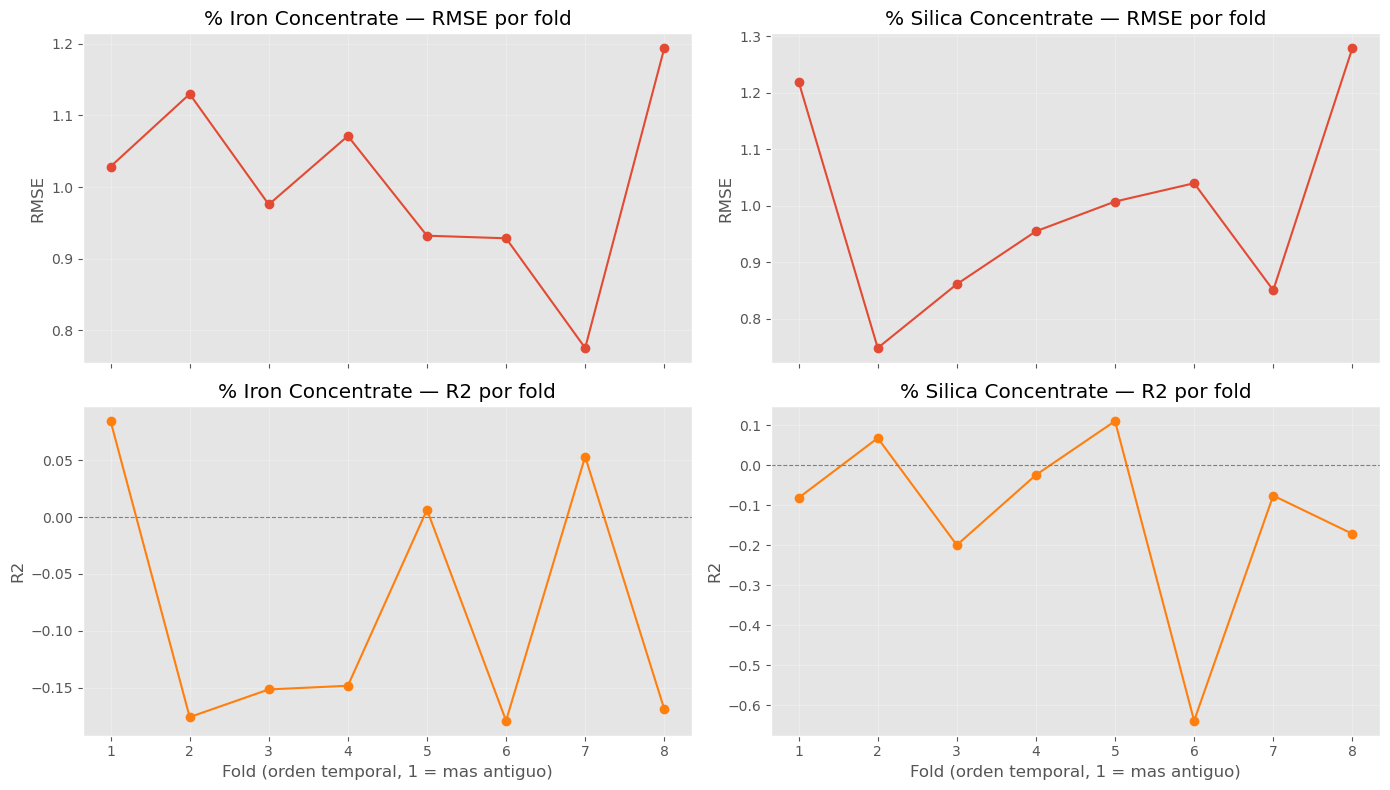

In [68]:
# --- Backtest de ventana deslizante (rolling-origin, walk-forward) ---
# El grid search de arriba solo da el RMSE PROMEDIADO entre los folds de
# walk-forward: si el modelo mejora o empeora segun avanza la campana, ese
# promedio lo esconde. Aqui reentrenamos con los mejores hiperparametros del
# grid search en cada fold por separado y guardamos el score de cada uno,
# para ver la tendencia fold a fold en vez de un unico numero agregado.
#
# Reusa los mismos folds 'tscv' (lista de (train_idx, val_idx)) definidos en
# la celda de grid search: ventana DESLIZANTE de tamano fijo (TRAIN_SIZE/
# VAL_SIZE), no expanding, así que la proporcion val/train es 80/20 en TODOS
# los folds, no solo en el ultimo.

best_params_flat = {k.replace('estimator__', ''): v for k, v in grid_search.best_params_.items()}

rolling_results = []
for fold_num, (train_idx, val_idx) in enumerate(tscv, start=1):
    X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    fold_model = MultiOutputRegressor(
        XGBRegressor(**best_params_flat, random_state=21, n_jobs=-1, tree_method='hist')
    )
    fold_model.fit(X_tr, y_tr)
    y_pred_val = pd.DataFrame(fold_model.predict(X_val), index=y_val.index, columns=TARGET)

    for col in TARGET:
        rolling_results.append({
            'fold': fold_num,
            'val_start': X_val.index.min(),
            'val_end': X_val.index.max(),
            'n_train': len(train_idx),
            'n_val': len(val_idx),
            'target': col,
            'RMSE': mean_squared_error(y_val[col], y_pred_val[col]) ** 0.5,
            'MAE': mean_absolute_error(y_val[col], y_pred_val[col]),
            'R2': r2_score(y_val[col], y_pred_val[col]),
        })

rolling_df = pd.DataFrame(rolling_results)
print(rolling_df.to_string(index=False))

# --- Grafica: RMSE y R2 por fold, un panel por target ---
# Si el modelo mejora al avanzar en el tiempo (mas historico disponible,
# o el proceso se vuelve mas predecible), el RMSE deberia bajar y el R2
# subir de izquierda a derecha. Una linea plana o que empeora sugiere que
# mas datos de entrenamiento no ayudan (o que el proceso cambia de regimen).
fig, axes = plt.subplots(2, len(TARGET), figsize=(7 * len(TARGET), 8), sharex=True)
for j, col in enumerate(TARGET):
    sub = rolling_df[rolling_df['target'] == col]
    axes[0, j].plot(sub['fold'], sub['RMSE'], marker='o')
    axes[0, j].set_title(f'{col} — RMSE por fold')
    axes[0, j].set_ylabel('RMSE')
    axes[0, j].grid(alpha=0.3)

    axes[1, j].plot(sub['fold'], sub['R2'], marker='o', color='tab:orange')
    axes[1, j].set_title(f'{col} — R2 por fold')
    axes[1, j].set_ylabel('R2')
    axes[1, j].set_xlabel('Fold (orden temporal, 1 = mas antiguo)')
    axes[1, j].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[1, j].grid(alpha=0.3)

plt.tight_layout()
plt.show()


     % Iron Concentrate                                         \
        naive_constante naive_drift xgboost_test xgboost_train   
RMSE           0.823104    1.347382     1.167640      0.845793   
MAE            0.577030    0.967575     0.891434      0.665474   
R2             0.465612   -0.432067    -0.075861      0.407069   

     % Silica Concentrate                                         
          naive_constante naive_drift xgboost_test xgboost_train  
RMSE             0.729469    1.149918     1.111163      0.822602  
MAE              0.447335    0.722855     0.856357      0.647858  
R2               0.604964    0.016879     0.082456      0.458079  


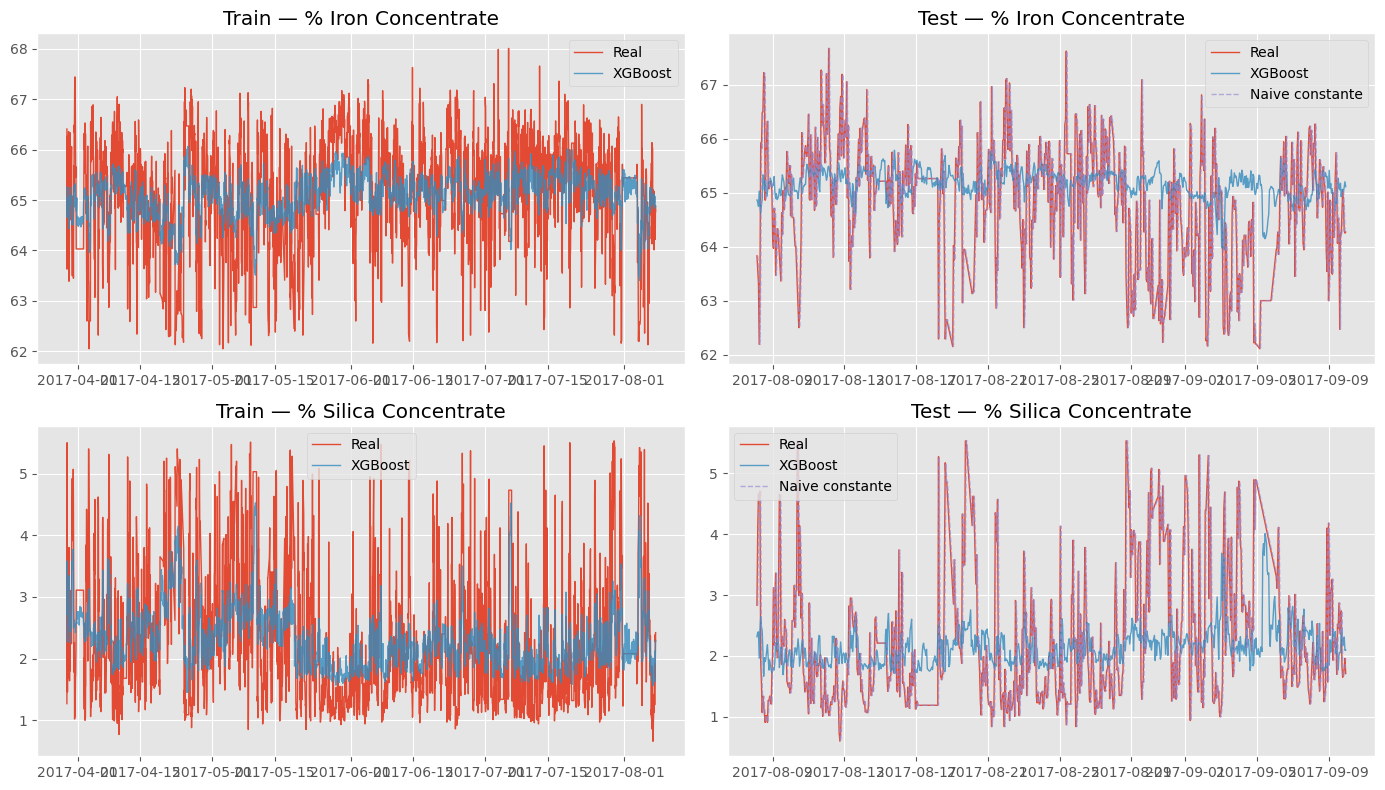

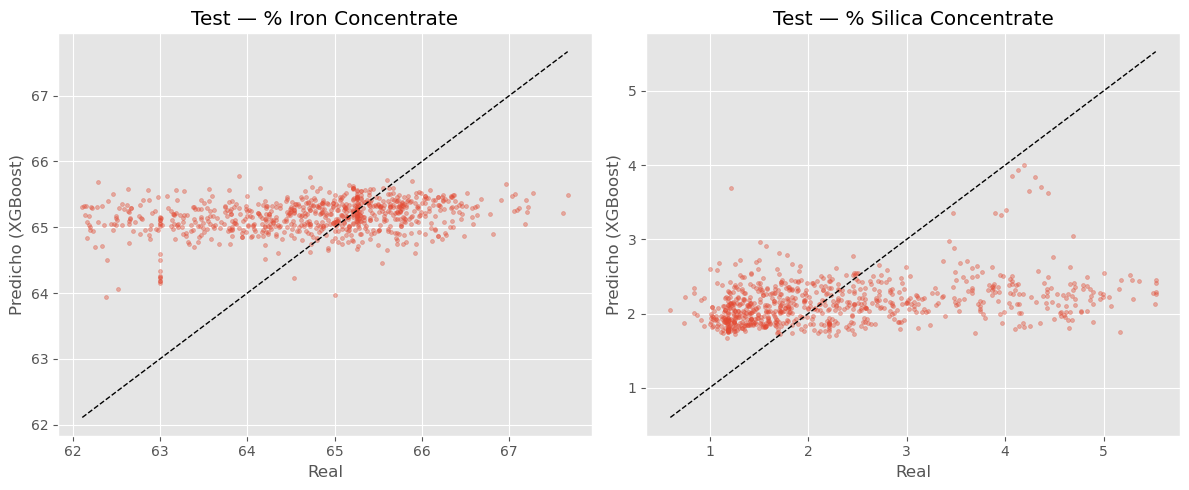

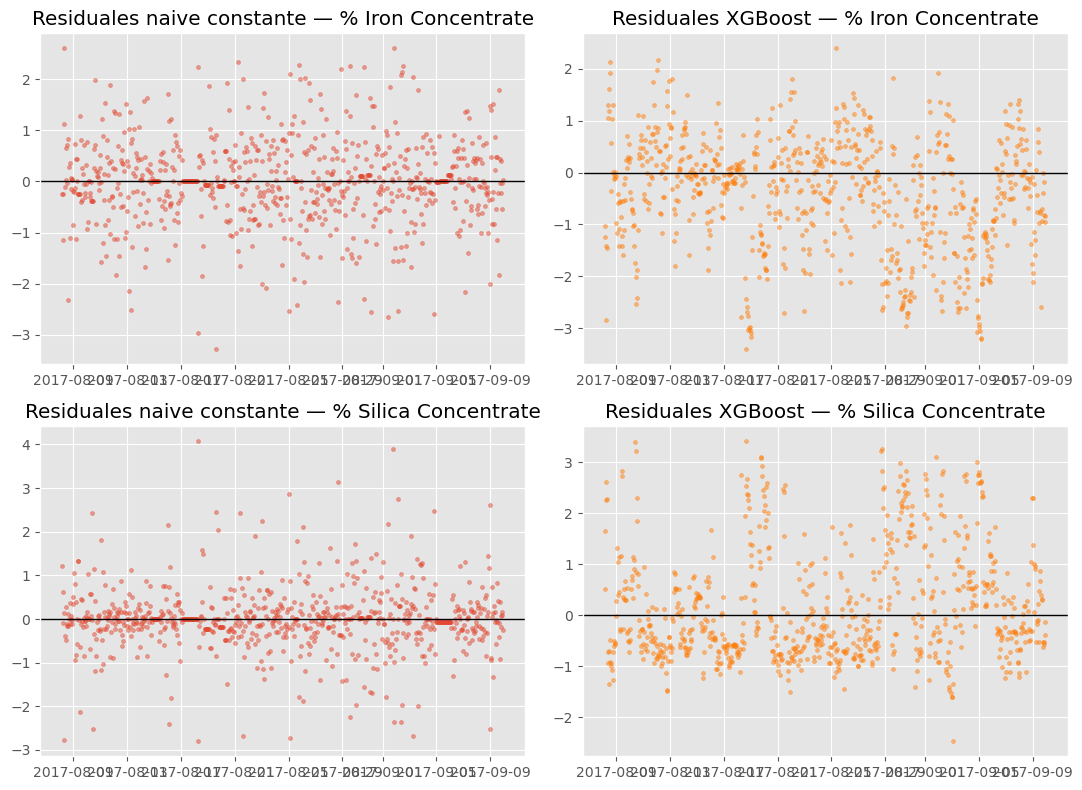

In [69]:
# --- Naive baselines realimentados (persistencia clasica de forecasting a 1 paso):
# usan el valor REAL del target en t (y t-1 para el drift) para predecir t+1, a
# diferencia de un naive "ciego" que no se realimenta. Se evalua sobre el tramo
# de test en resolucion horaria SIN desplazar (df[TARGET], no y_test que ya esta
# shiftado -HORIZON para el XGBoost).
target_series_test = df.loc[X_test.index.min():X_test.index.max(), TARGET]

# ============================================================
# NAIVE CONSTANTE (persistencia): pred(t+1) = target(t)
# ============================================================
def evaluate_naive_constant(df_eval, target_col):
    y_true = df_eval[target_col].iloc[1:].values          # valores reales en t+1
    y_pred = df_eval[target_col].iloc[:-1].values          # prediccion = valor en t
    return y_true, y_pred

# ============================================================
# NAIVE CON DRIFT: pred(t+1) = target(t) + [target(t) - target(t-1)]
# Requiere al menos 2 puntos de historia antes de poder predecir
# ============================================================
def evaluate_naive_drift(df_eval, target_col):
    y = df_eval[target_col].values
    y_true = y[2:]                          # valor real en t+1, empezando desde el 3er punto
    y_t     = y[1:-1]                       # valor en t
    y_t_1   = y[0:-2]                       # valor en t-1
    y_pred  = y_t + (y_t - y_t_1)           # persistencia + tendencia del paso anterior
    return y_true, y_pred

# --- Metricas: RMSE, MAE y R^2 (nunca solo R^2, como exige el criterio del proyecto) ---
naive_results = {}
for col in TARGET:
    yt_c, yp_c = evaluate_naive_constant(target_series_test, col)
    yt_d, yp_d = evaluate_naive_drift(target_series_test, col)

    naive_results[col] = {
        'naive_constante': {
            'RMSE': mean_squared_error(yt_c, yp_c) ** 0.5,
            'MAE': mean_absolute_error(yt_c, yp_c),
            'R2': r2_score(yt_c, yp_c),
        },
        'naive_drift': {
            'RMSE': mean_squared_error(yt_d, yp_d) ** 0.5,
            'MAE': mean_absolute_error(yt_d, yp_d),
            'R2': r2_score(yt_d, yp_d),
        },
        'xgboost_test': {
            'RMSE': mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_test[col], y_pred_model[col]),
            'R2': r2_score(y_test[col], y_pred_model[col]),
        },
        'xgboost_train': {
            'RMSE': mean_squared_error(y_train[col], y_pred_train_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_train[col], y_pred_train_model[col]),
            'R2': r2_score(y_train[col], y_pred_train_model[col]),
        },
    }

results = pd.DataFrame({(t, m): naive_results[t][m] for t in naive_results for m in naive_results[t]})
print(results)

# Predicciones naive realineadas al indice del target (para graficar junto al XGBoost)
y_pred_naive_const = pd.DataFrame(
    {col: evaluate_naive_constant(target_series_test, col)[1] for col in TARGET},
    index=target_series_test.index[1:],
)

# --- Graficas de prediccion: real vs. predicho, train y test, por target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    axes[i, 0].plot(y_train.index, y_train[col], label='Real', linewidth=1)
    axes[i, 0].plot(y_pred_train_model.index, y_pred_train_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 0].set_title(f'Train — {col}')
    axes[i, 0].legend()

    axes[i, 1].plot(y_test.index, y_test[col], label='Real', linewidth=1)
    axes[i, 1].plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 1].plot(y_pred_naive_const.index, y_pred_naive_const[col], label='Naive constante', linewidth=1, linestyle='--', alpha=0.7)
    axes[i, 1].set_title(f'Test — {col}')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

# --- Scatter real vs. predicho (test), por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(6 * len(TARGET), 5))
for i, col in enumerate(TARGET):
    ax = axes[i]
    ax.scatter(y_test[col], y_pred_model[col], s=8, alpha=0.4)
    lims = [min(y_test[col].min(), y_pred_model[col].min()), max(y_test[col].max(), y_pred_model[col].max())]
    ax.plot(lims, lims, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho (XGBoost)')
    ax.set_title(f'Test — {col}')

plt.tight_layout()
plt.show()

# --- Residual plots: modelo vs. naive constante, para cada target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(11, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    resid_naive = target_series_test[col].iloc[1:].values - y_pred_naive_const[col].values
    resid_model = y_test[col] - y_pred_model[col]

    axes[i, 0].scatter(y_pred_naive_const.index, resid_naive, s=8, alpha=0.5)
    axes[i, 0].axhline(0, color='black', linewidth=1)
    axes[i, 0].set_title(f'Residuales naive constante — {col}')

    axes[i, 1].scatter(y_test.index, resid_model, s=8, alpha=0.5, color='tab:orange')
    axes[i, 1].axhline(0, color='black', linewidth=1)
    axes[i, 1].set_title(f'Residuales XGBoost — {col}')

plt.tight_layout()
plt.show()

In [83]:
# --- LSTM (Keras) con contexto temporal real ---
# El bloque anterior (ahora sustituido) le pasaba a la LSTM X_train_scaled, que
# viene de X_all: cada variable ya esta desplazada a UN lag fijo (0, 1 o 3h) y
# el reshape a timesteps=1 no le daba a la red ninguna secuencia que recorrer
# -- en la practica funcionaba como una red densa sobre datos tabulares, no
# como un modelo secuencial.
#
# Aqui se usan las mismas 6 variables base (sin pre-desplazar por lag como en
# XGBoost) tomadas directamente de 'df' (agregado horario), y para cada hora
# se construye una ventana de las WINDOW=12 horas anteriores. Cada muestra que
# ve la LSTM es entonces una secuencia real (12, n_features), y el target es
# el valor de TARGET en la hora siguiente a la ventana -- asi la recurrencia
# tiene series temporales genuinas sobre las que aprender dinamica, no un
# unico vector por muestra.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

WINDOW = 12  # horas de contexto que ve la LSTM en cada muestra

LSTM_FEATURE_COLS = [
    'Ore Pulp Density_mean',
    'Flotation Column 05 Air Flow_mean',
    'Amina Flow_mean',
    'Feed Iron_Silica_Mean',
    'Air Flow 1_2_3_Mean_mean',
    'Ore Pulp pH_mean',
]

lstm_raw = df[LSTM_FEATURE_COLS + TARGET].dropna()

# Mismo split temporal 70/30 que XGBoost, aplicado ANTES de construir las
# ventanas: asi ninguna ventana de train contiene horas del tramo de test.
lstm_split_idx = int(len(lstm_raw) * 0.8)
lstm_train_raw = lstm_raw.iloc[:lstm_split_idx]
lstm_test_raw = lstm_raw.iloc[lstm_split_idx:]

# Escalado z-score fit SOLO en train (igual que X_train_scaled/X_test_scaled
# del bloque XGBoost), para no filtrar estadisticos del test.
lstm_feat_mean = lstm_train_raw[LSTM_FEATURE_COLS].mean()
lstm_feat_std = lstm_train_raw[LSTM_FEATURE_COLS].std()

# El target tambien se normaliza (z-score, fit SOLO en train), ademas de las
# features. Sin esto, con loss='mae' en escala original (~60-68% Iron,
# ~1-6% Silica) el gradiente inicial mas facil de aprovechar es simplemente
# ajustar el sesgo de la capa Dense final hacia la media del target -- eso
# minimiza el MAE rapido al principio y, combinado con un EarlyStopping
# demasiado impaciente, deja al modelo "congelado" prediciendo casi una
# constante (la linea plana). Normalizar el target pone el gradiente en una
# escala donde aprender la dinamica real compite en igualdad con aprender la
# media.
lstm_target_mean = lstm_train_raw[TARGET].mean()
lstm_target_std = lstm_train_raw[TARGET].std()


def make_windows(raw_df, feat_mean, feat_std, target_mean, target_std, window=WINDOW):
    """De un DataFrame horario (features + TARGET) construye secuencias
    (window, n_features) y su target normalizado: la ventana [t-window, t)
    predice el valor de TARGET en t (la hora siguiente a la ventana)."""
    feats_scaled = (raw_df[LSTM_FEATURE_COLS] - feat_mean) / feat_std
    target_scaled = (raw_df[TARGET] - target_mean) / target_std
    X_seq, y_seq, idx_seq = [], [], []
    values = feats_scaled.values
    targets = target_scaled.values
    index = raw_df.index
    for i in range(window, len(raw_df)):
        X_seq.append(values[i - window:i])
        y_seq.append(targets[i])
        idx_seq.append(index[i])
    return np.array(X_seq), np.array(y_seq), pd.DatetimeIndex(idx_seq)


train_X_lstm, train_y_lstm_scaled, train_idx_lstm = make_windows(
    lstm_train_raw, lstm_feat_mean, lstm_feat_std, lstm_target_mean, lstm_target_std)
test_X_lstm, test_y_lstm_scaled, test_idx_lstm = make_windows(
    lstm_test_raw, lstm_feat_mean, lstm_feat_std, lstm_target_mean, lstm_target_std)

# DataFrames propios de la LSTM en escala ORIGINAL (no la normalizada que se
# usa para entrenar) -- son los que usan las celdas de metricas/graficas de
# mas abajo. NO se llaman y_train/y_test: las ventanas tienen distinto numero
# de filas e indice que el split de XGBoost (se pierden las primeras WINDOW
# horas de cada tramo), asi que reusar los nombres globales pisaria
# y_train/y_test y romperia XGBoost si se reejecuta despues.
y_train_lstm = lstm_train_raw[TARGET].iloc[WINDOW:]
y_test_lstm = lstm_test_raw[TARGET].iloc[WINDOW:]
train_y_lstm = train_y_lstm_scaled  # lo que se le pasa a model.fit (escala normalizada)
test_y_lstm = test_y_lstm_scaled

n_targets_lstm = len(TARGET)
n_features_lstm = len(LSTM_FEATURE_COLS)

print(f'train_X_lstm: {train_X_lstm.shape}, train_y_lstm: {train_y_lstm.shape}')
print(f'test_X_lstm : {test_X_lstm.shape}, test_y_lstm : {test_y_lstm.shape}')
print(f'Ventana: {WINDOW}h de contexto -> predice TARGET en la hora siguiente')

lstm_model = Sequential([
    LSTM(units=128,
         return_sequences=True,
         input_shape=(train_X_lstm.shape[1], train_X_lstm.shape[2])),
    LSTM(units=128),
    Dense(n_targets_lstm)   # una salida por target: [Iron, Silica]
])
lstm_model.compile(
    loss='mae',
    optimizer='adam')
lstm_model.summary()

history = lstm_model.fit(
    train_X_lstm,
    train_y_lstm,
    epochs=500,
    batch_size=32,
    validation_data=(test_X_lstm, test_y_lstm),
    verbose=2,
    shuffle=False,
    callbacks=[
        ModelCheckpoint('./LSTM_Flotation_ML.keras', save_best_only=True),
        # patience=0 cortaba el entrenamiento en cuanto la loss de validacion
        # empeoraba una sola epoca -- casi siempre en la epoca 1-2, mientras
        # el modelo todavia esta en la fase de "predecir la media" (la
        # solucion mas facil de bajar el MAE al principio). Con mas paciencia
        # y un min_delta que ignore mejoras insignificantes, el modelo tiene
        # margen real para aprender la dinamica antes de que se le detenga.
        EarlyStopping(patience=50, min_delta=1e-4, restore_best_weights=True),
    ])


train_X_lstm: (3146, 12, 6), train_y_lstm: (3146, 2)
test_X_lstm : (778, 12, 6), test_y_lstm : (778, 2)
Ventana: 12h de contexto -> predice TARGET en la hora siguiente


c:\Users\COMPUTAEX\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 12, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,962 (785.01 KB)

 Trainable params: 200,962 (785.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
99/99 - 3s - 32ms/step - loss: 0.7970 - val_loss: 0.8016
Epoch 2/500
99/99 - 1s - 13ms/step - loss: 0.7650 - val_loss: 0.7943
Epoch 3/500
99/99 - 1s - 14ms/step - loss: 0.7501 - val_loss: 0.7963
Epoch 4/500
99/99 - 1s - 14ms/step - loss: 0.7483 - val_loss: 0.8021
Epoch 5/500
99/99 - 1s - 13ms/step - loss: 0.7389 - val_loss: 0.8006
Epoch 6/500
99/99 - 1s - 13ms/step - loss: 0.7391 - val_loss: 0.8059
Epoch 7/500
99/99 - 1s - 14ms/step - loss: 0.7376 - val_loss: 0.8049
Epoch 8/500
99/99 - 1s - 14ms/step - loss: 0.7237 - val_loss: 0.8001
Epoch 9/500
99/99 - 1s - 13ms/step - loss: 0.7274 - val_loss: 0.8171
Epoch 10/500
99/99 - 1s - 14ms/step - loss: 0.7198 - val_loss: 0.8071
Epoch 11/500
99/99 - 1s - 14ms/step - loss: 0.7112 - val_loss: 0.8186
Epoch 12/500
99/99 - 1s - 13ms/step - loss: 0.7170 - val_loss: 0.8071
Epoch 13/500
99/99 - 1s - 13ms/step - loss: 0.7021 - val_loss: 0.8218
Epoch 14/500
99/99 - 1s - 13ms/step - loss: 0.6958 - val_loss: 0.8151
Epoch 15/500
99/99 - 1s - 14m

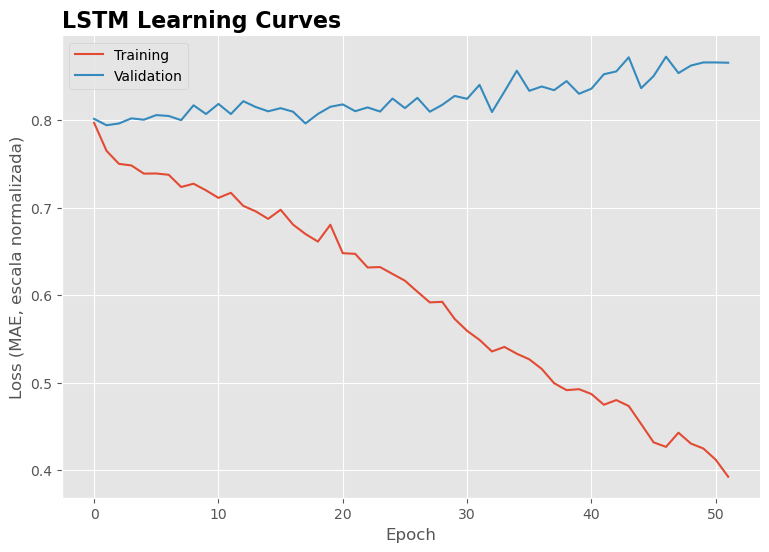

Best training loss   = 0.3924 at epoch 51
Best validation loss = 0.7943 at epoch 1


In [84]:
# --- Curvas de aprendizaje ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_loss, label='Training')
ax.plot(val_loss, label='Validation')
ax.set_title('LSTM Learning Curves', loc='left', weight='bold', size=16)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MAE, escala normalizada)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

print(f'Best training loss   = {min(train_loss):.4f} at epoch {train_loss.index(min(train_loss))}')
print(f'Best validation loss = {min(val_loss):.4f} at epoch {val_loss.index(min(val_loss))}')

In [85]:
# --- Prediccion y metricas LSTM, mismas metricas y mismo formato que XGBoost/naive ---
# El modelo se entreno con el target NORMALIZADO (z-score, ver celda anterior),
# asi que predict() devuelve valores en esa misma escala normalizada. Hay que
# deshacer la normalizacion (lstm_target_mean/std, fit en train) antes de
# comparar contra y_train_lstm/y_test_lstm, que estan en la escala ORIGINAL.
# Usa y_train_lstm/y_test_lstm (propios de la LSTM, con ventanas de WINDOW
# horas), NO y_train/y_test de XGBoost -- tienen distinto indice/tamano.
y_pred_train_lstm_scaled = pd.DataFrame(lstm_model.predict(train_X_lstm), index=y_train_lstm.index, columns=TARGET)
y_pred_test_lstm_scaled = pd.DataFrame(lstm_model.predict(test_X_lstm), index=y_test_lstm.index, columns=TARGET)

y_pred_train_lstm = y_pred_train_lstm_scaled * lstm_target_std + lstm_target_mean
y_pred_test_lstm = y_pred_test_lstm_scaled * lstm_target_std + lstm_target_mean

lstm_results = {}
for col in TARGET:
    lstm_results[col] = {
        'lstm_train': {
            'RMSE': mean_squared_error(y_train_lstm[col], y_pred_train_lstm[col]) ** 0.5,
            'MAE': mean_absolute_error(y_train_lstm[col], y_pred_train_lstm[col]),
            'R2': r2_score(y_train_lstm[col], y_pred_train_lstm[col]),
        },
        'lstm_test': {
            'RMSE': mean_squared_error(y_test_lstm[col], y_pred_test_lstm[col]) ** 0.5,
            'MAE': mean_absolute_error(y_test_lstm[col], y_pred_test_lstm[col]),
            'R2': r2_score(y_test_lstm[col], y_pred_test_lstm[col]),
        },
    }

lstm_results_df = pd.DataFrame({(t, m): lstm_results[t][m] for t in lstm_results for m in lstm_results[t]})
print(lstm_results_df)


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
     % Iron Concentrate           % Silica Concentrate          
             lstm_train lstm_test           lstm_train lstm_test
RMSE           1.065298  1.151591             1.082090  1.182246
MAE            0.822101  0.883537             0.811165  0.877005
R2             0.059829 -0.067698             0.061915 -0.049470


                                          RMSE       MAE        R2
target               method                                       
% Iron Concentrate   naive_constante  0.823104  0.577030  0.465612
                     naive_drift      1.347382  0.967575 -0.432067
                     xgboost_test     1.167640  0.891434 -0.075861
                     lstm_test        1.151591  0.883537 -0.067698
% Silica Concentrate naive_constante  0.729469  0.447335  0.604964
                     naive_drift      1.149918  0.722855  0.016879
                     xgboost_test     1.111163  0.856357  0.082456
                     lstm_test        1.182246  0.877005 -0.049470


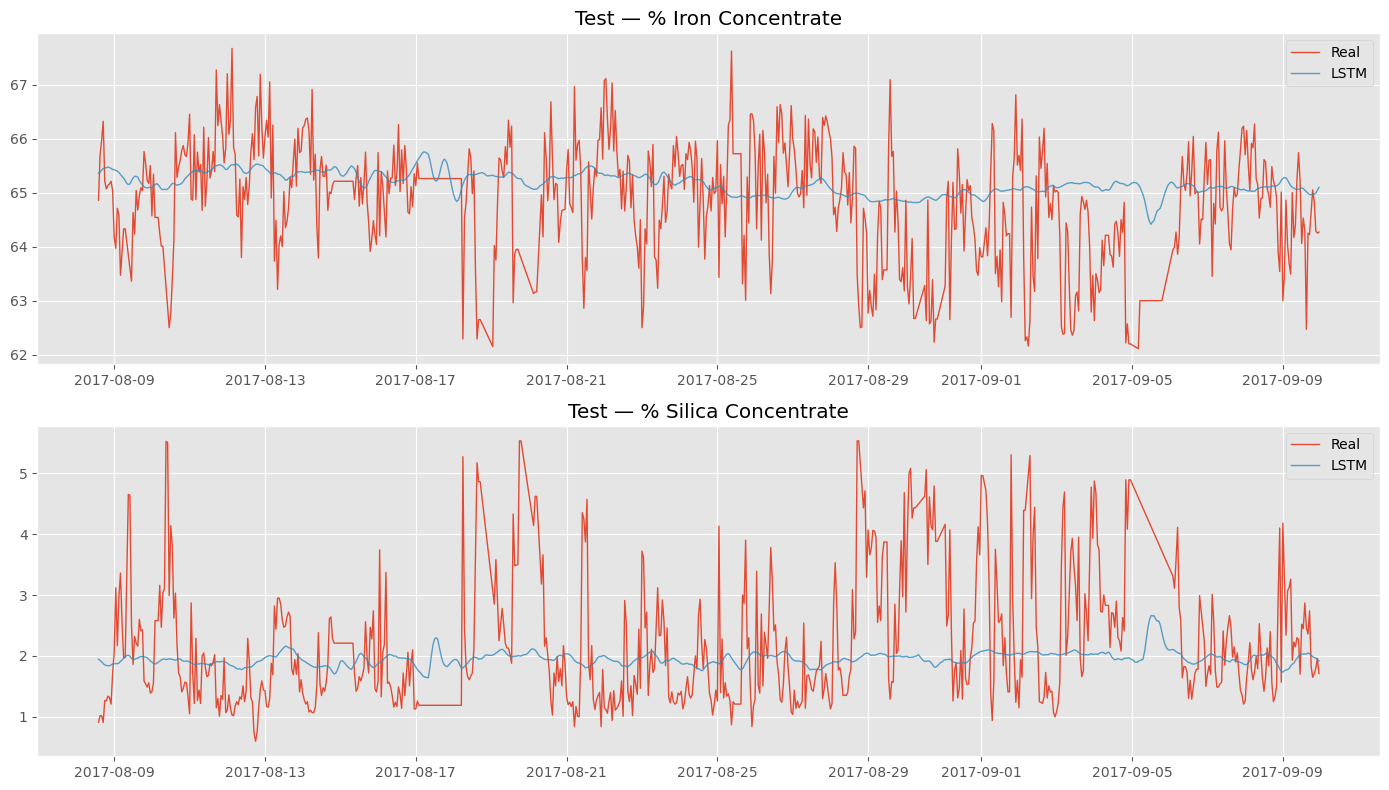

In [86]:
# --- Comparativa final: LSTM vs. XGBoost vs. naive baselines (test), por target ---
# Reusa xgboost_test/naive_constante/naive_drift ya calculados en naive_results
# (celda anterior) para no repetir esos calculos.
comparison_rows = []
for col in TARGET:
    for method, metrics in [
        ('naive_constante', naive_results[col]['naive_constante']),
        ('naive_drift', naive_results[col]['naive_drift']),
        ('xgboost_test', naive_results[col]['xgboost_test']),
        ('lstm_test', lstm_results[col]['lstm_test']),
    ]:
        comparison_rows.append({'target': col, 'method': method, **metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index(['target', 'method'])
print(comparison_df)

# --- Graficas: real vs. predicho (test), LSTM vs. XGBoost, por target ---
fig, axes = plt.subplots(len(TARGET), 1, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    ax = axes[i] if len(TARGET) > 1 else axes
    # y_test_lstm (no y_test de XGBoost): la LSTM pierde las primeras WINDOW
    # horas de cada tramo al construir las ventanas, asi que su tramo de test
    # tiene distinto indice/tamano que el de XGBoost.
    ax.plot(y_test_lstm.index, y_test_lstm[col], label='Real', linewidth=1)
    # ax.plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    ax.plot(y_pred_test_lstm.index, y_pred_test_lstm[col], label='LSTM', linewidth=1, alpha=0.8)
    ax.set_title(f'Test — {col}')
    ax.legend()

plt.tight_layout()
plt.show()